Shape : (8000, 34)
Taux d'annulation : 0.2584


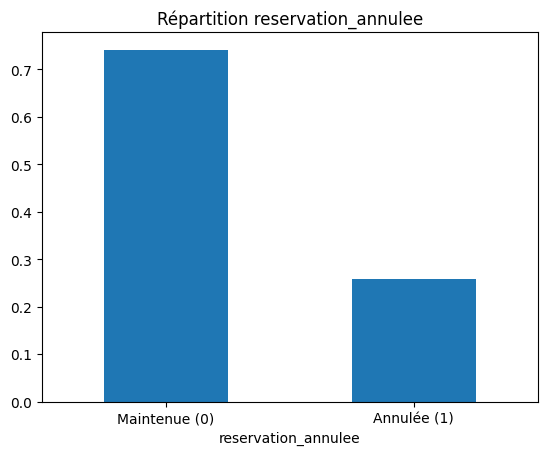


Train - date_reservation : 2023-01-01 00:00:00 -> 2025-05-24 00:00:00

Valeurs manquantes :
 agent_id               3354
enfants                 355
prix_moyen_nuit_eur     193
marche_origine          191
demandes_speciales      157
dtype: int64

En % :
 agent_id               41.9
enfants                 4.4
prix_moyen_nuit_eur     2.4
marche_origine          2.4
demandes_speciales      2.0
dtype: float64
hotel_id -> 84 valeurs uniques
agent_id -> 45 valeurs uniques


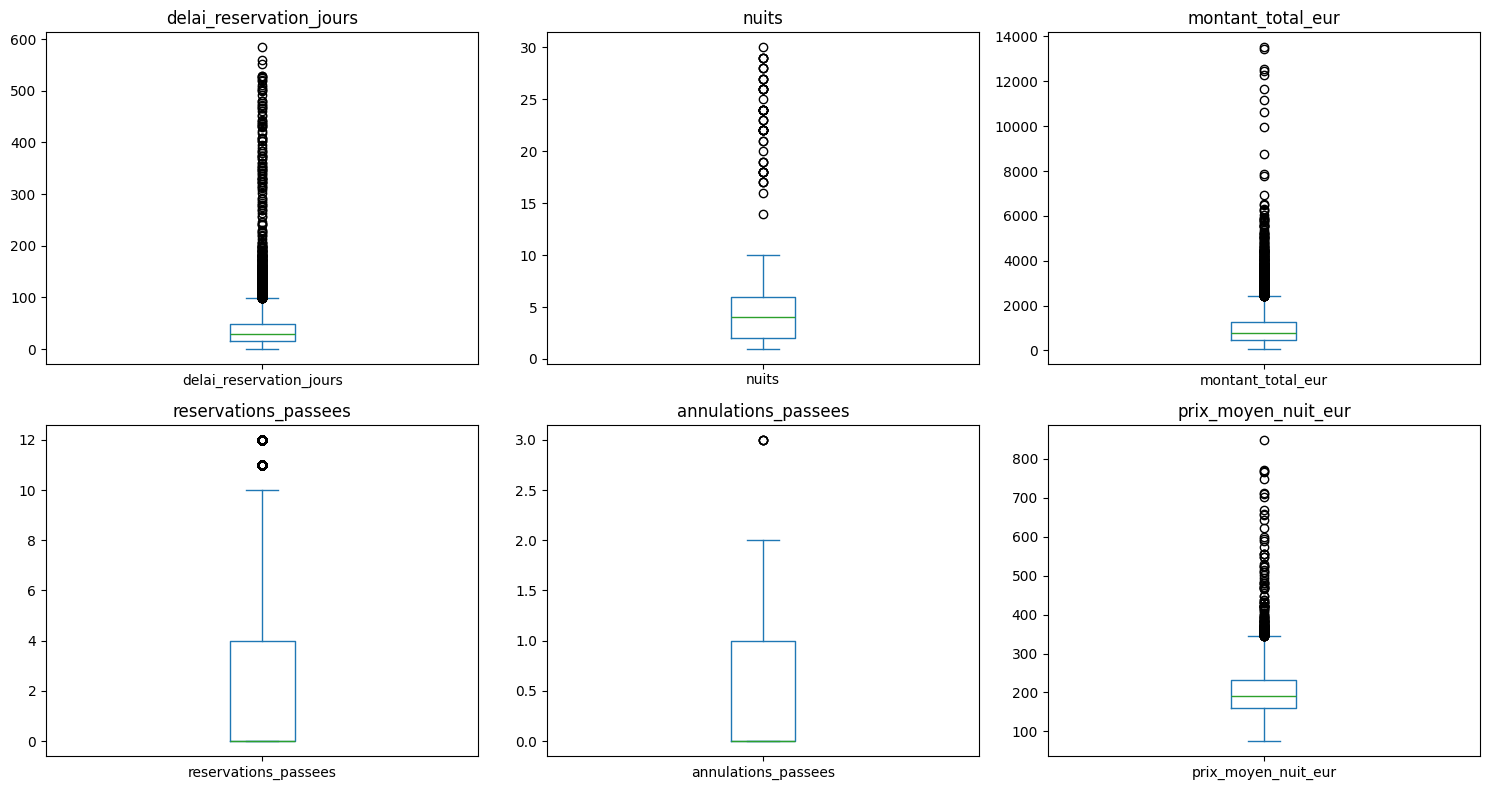


Train_sub : 6400 lignes (2023-01-01 -> 2024-11-28)
Val       : 1600 lignes (2024-11-28 -> 2025-05-24)

Colonnes numériques : ['categorie_hotel', 'delai_reservation_jours', 'nuits', 'adultes', 'enfants', 'chambres', 'prix_moyen_nuit_eur', 'remise_pct', 'montant_total_eur', 'reservations_passees', 'annulations_passees', 'demandes_speciales', 'modifications_reservation', 'jours_liste_attente', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend']
Colonnes catégorielles : ['region_hotel', 'ville', 'type_destination', 'segment_client', 'marche_origine', 'canal_reservation', 'moyen_transport', 'formule_repas', 'tarif_remboursable', 'type_acompte', 'client_type']

>>> F1-score BASELINE (seuil=0.5, classe annulation) : 0.4541

Rapport de classification :
              precision    recall  f1-score   support

           0      0.809     0.605     0.692      1171
           1      0.361     0.611     0.454       429

    accuracy                          0.606      1600
   macro avg 

In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42  


df = pd.read_csv("atlantic-haven-main/ressources/reservations_train.csv")

TARGET_COL = "reservation_annulee"
DATE_COL = "date_reservation"
ID_COL = "reservation_id"

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df["date_arrivee"] = pd.to_datetime(df["date_arrivee"])

print("Shape :", df.shape)
print("Taux d'annulation :", df[TARGET_COL].mean().round(4))


df[TARGET_COL].value_counts(normalize=True).plot(
    kind="bar", title="Répartition reservation_annulee")
plt.xticks([0, 1], ["Maintenue (0)", "Annulée (1)"], rotation=0)
plt.show()

print("\nTrain - date_reservation :", df[DATE_COL].min(), "->", df[DATE_COL].max())


missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nValeurs manquantes :\n", missing)
print("\nEn % :\n", (missing / len(df) * 100).round(1))

for c in ["hotel_id", "agent_id"]:
    print(c, "->", df[c].nunique(), "valeurs uniques")



num_check = ["delai_reservation_jours", "nuits", "montant_total_eur",
             "reservations_passees", "annulations_passees", "prix_moyen_nuit_eur"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), num_check):
    df[c].plot(kind="box", ax=ax, title=c)
plt.tight_layout()
plt.show()

def temporal_split(df, date_col, frac_train=0.8):
    """Trie par date et coupe en train_sub / val (PAS de shuffle, PAS de K-Fold)."""
    df_sorted = df.sort_values(date_col).reset_index(drop=True)
    idx = int(len(df_sorted) * frac_train)
    return df_sorted.iloc[:idx].copy(), df_sorted.iloc[idx:].copy()

train_sub, val = temporal_split(df, DATE_COL, frac_train=0.8)

print(f"\nTrain_sub : {train_sub.shape[0]} lignes "
      f"({train_sub[DATE_COL].min().date()} -> {train_sub[DATE_COL].max().date()})")
print(f"Val       : {val.shape[0]} lignes "
      f"({val[DATE_COL].min().date()} -> {val[DATE_COL].max().date()})")


y_train = train_sub[TARGET_COL]
y_val = val[TARGET_COL]

cols_to_drop = [TARGET_COL, DATE_COL, "date_arrivee", ID_COL, "hotel_id", "agent_id"]
X_train = train_sub.drop(columns=cols_to_drop)
X_val = val.drop(columns=cols_to_drop)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("\nColonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced",random_state=RANDOM_STATE)),
])


model.fit(X_train, y_train)


y_proba = model.predict_proba(X_val)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

f1 = f1_score(y_val, y_pred, pos_label=1)
print(f"\n>>> F1-score BASELINE (seuil=0.5, classe annulation) : {f1:.4f}")
print("\nRapport de classification :")
print(classification_report(y_val, y_pred, digits=3))
print("Matrice de confusion :\n", confusion_matrix(y_val, y_pred))
